In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import scanpy.external as sce
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns
import os
import gc
import random
from scipy.sparse import csr_matrix, csc_matrix
from scipy.io import mmread
from scipy.stats import mannwhitneyu

In [2]:
sc.logging.print_header()
sc.settings.set_figure_params(dpi_save=600, facecolor='white', fontsize=7, format='pdf')

scanpy==1.10.3 anndata==0.10.9 umap==0.5.7 numpy==1.26.4 scipy==1.11.4 pandas==2.2.3 scikit-learn==1.5.2 statsmodels==0.14.4 igraph==0.11.8 louvain==0.8.1 pynndescent==0.5.13


In [3]:
random.seed(71444)

In [4]:
ad.logging.print_memory_usage()

Memory usage: current 0.54 GB, difference +0.54 GB


In [5]:
outdir = '/cluster/home/chenyulong/GSE165816/0.1out'
os.chdir(outdir)

In [30]:
adata=sc.read_h5ad("./Final_Fib.h5ad")

/cluster/home/chenyulong/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [18]:
adata.var

,n_cells,mt,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,highly_variable,means,dispersions,dispersions_norm,mean,std
A2M,26711,False,26711,3.560067,53.967980,206580.0,True,0.964646,2.219414,1.808402,0.508055,0.801381
AADAC,70,False,70,0.001741,99.879367,101.0,True,0.001622,0.890788,1.004609,0.000918,0.029668
AADACL2,469,False,469,0.012822,99.191756,744.0,True,0.000712,0.848128,0.904369,0.000389,0.020247
AASS,3381,False,3381,0.063815,94.173402,3703.0,True,0.078039,0.754701,0.684837,0.047823,0.202602
AATK,387,False,387,0.007445,99.333069,432.0,True,0.002650,2.487235,4.755888,0.000988,0.035529
...,...,...,...,...,...,...,...,...,...,...,...,...
ZSWIM5,322,False,322,0.005756,99.445086,334.0,True,0.004544,0.838477,0.881690,0.002721,0.048306
ZUFSP,50,False,50,0.000913,99.913833,53.0,True,0.001870,1.369576,2.129649,0.000873,0.033207
ZYG11A,49,False,49,0.000844,99.915557,49.0,True,0.000771,0.987415,1.231660,0.000391,0.021568
ZZZ3,133,False,133,0.002327,99.770796,135.0,True,0.009086,0.796170,0.782279,0.004998,0.073069


/cluster/home/chenyulong/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/tmp/ipykernel_156059/1080766187.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_long[df_long['gene'] == gene],
/tmp/ipykernel_156059/1080766187.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_long[df_long['gene'] == gene],
/tmp/ipykernel_156059/1080766187.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

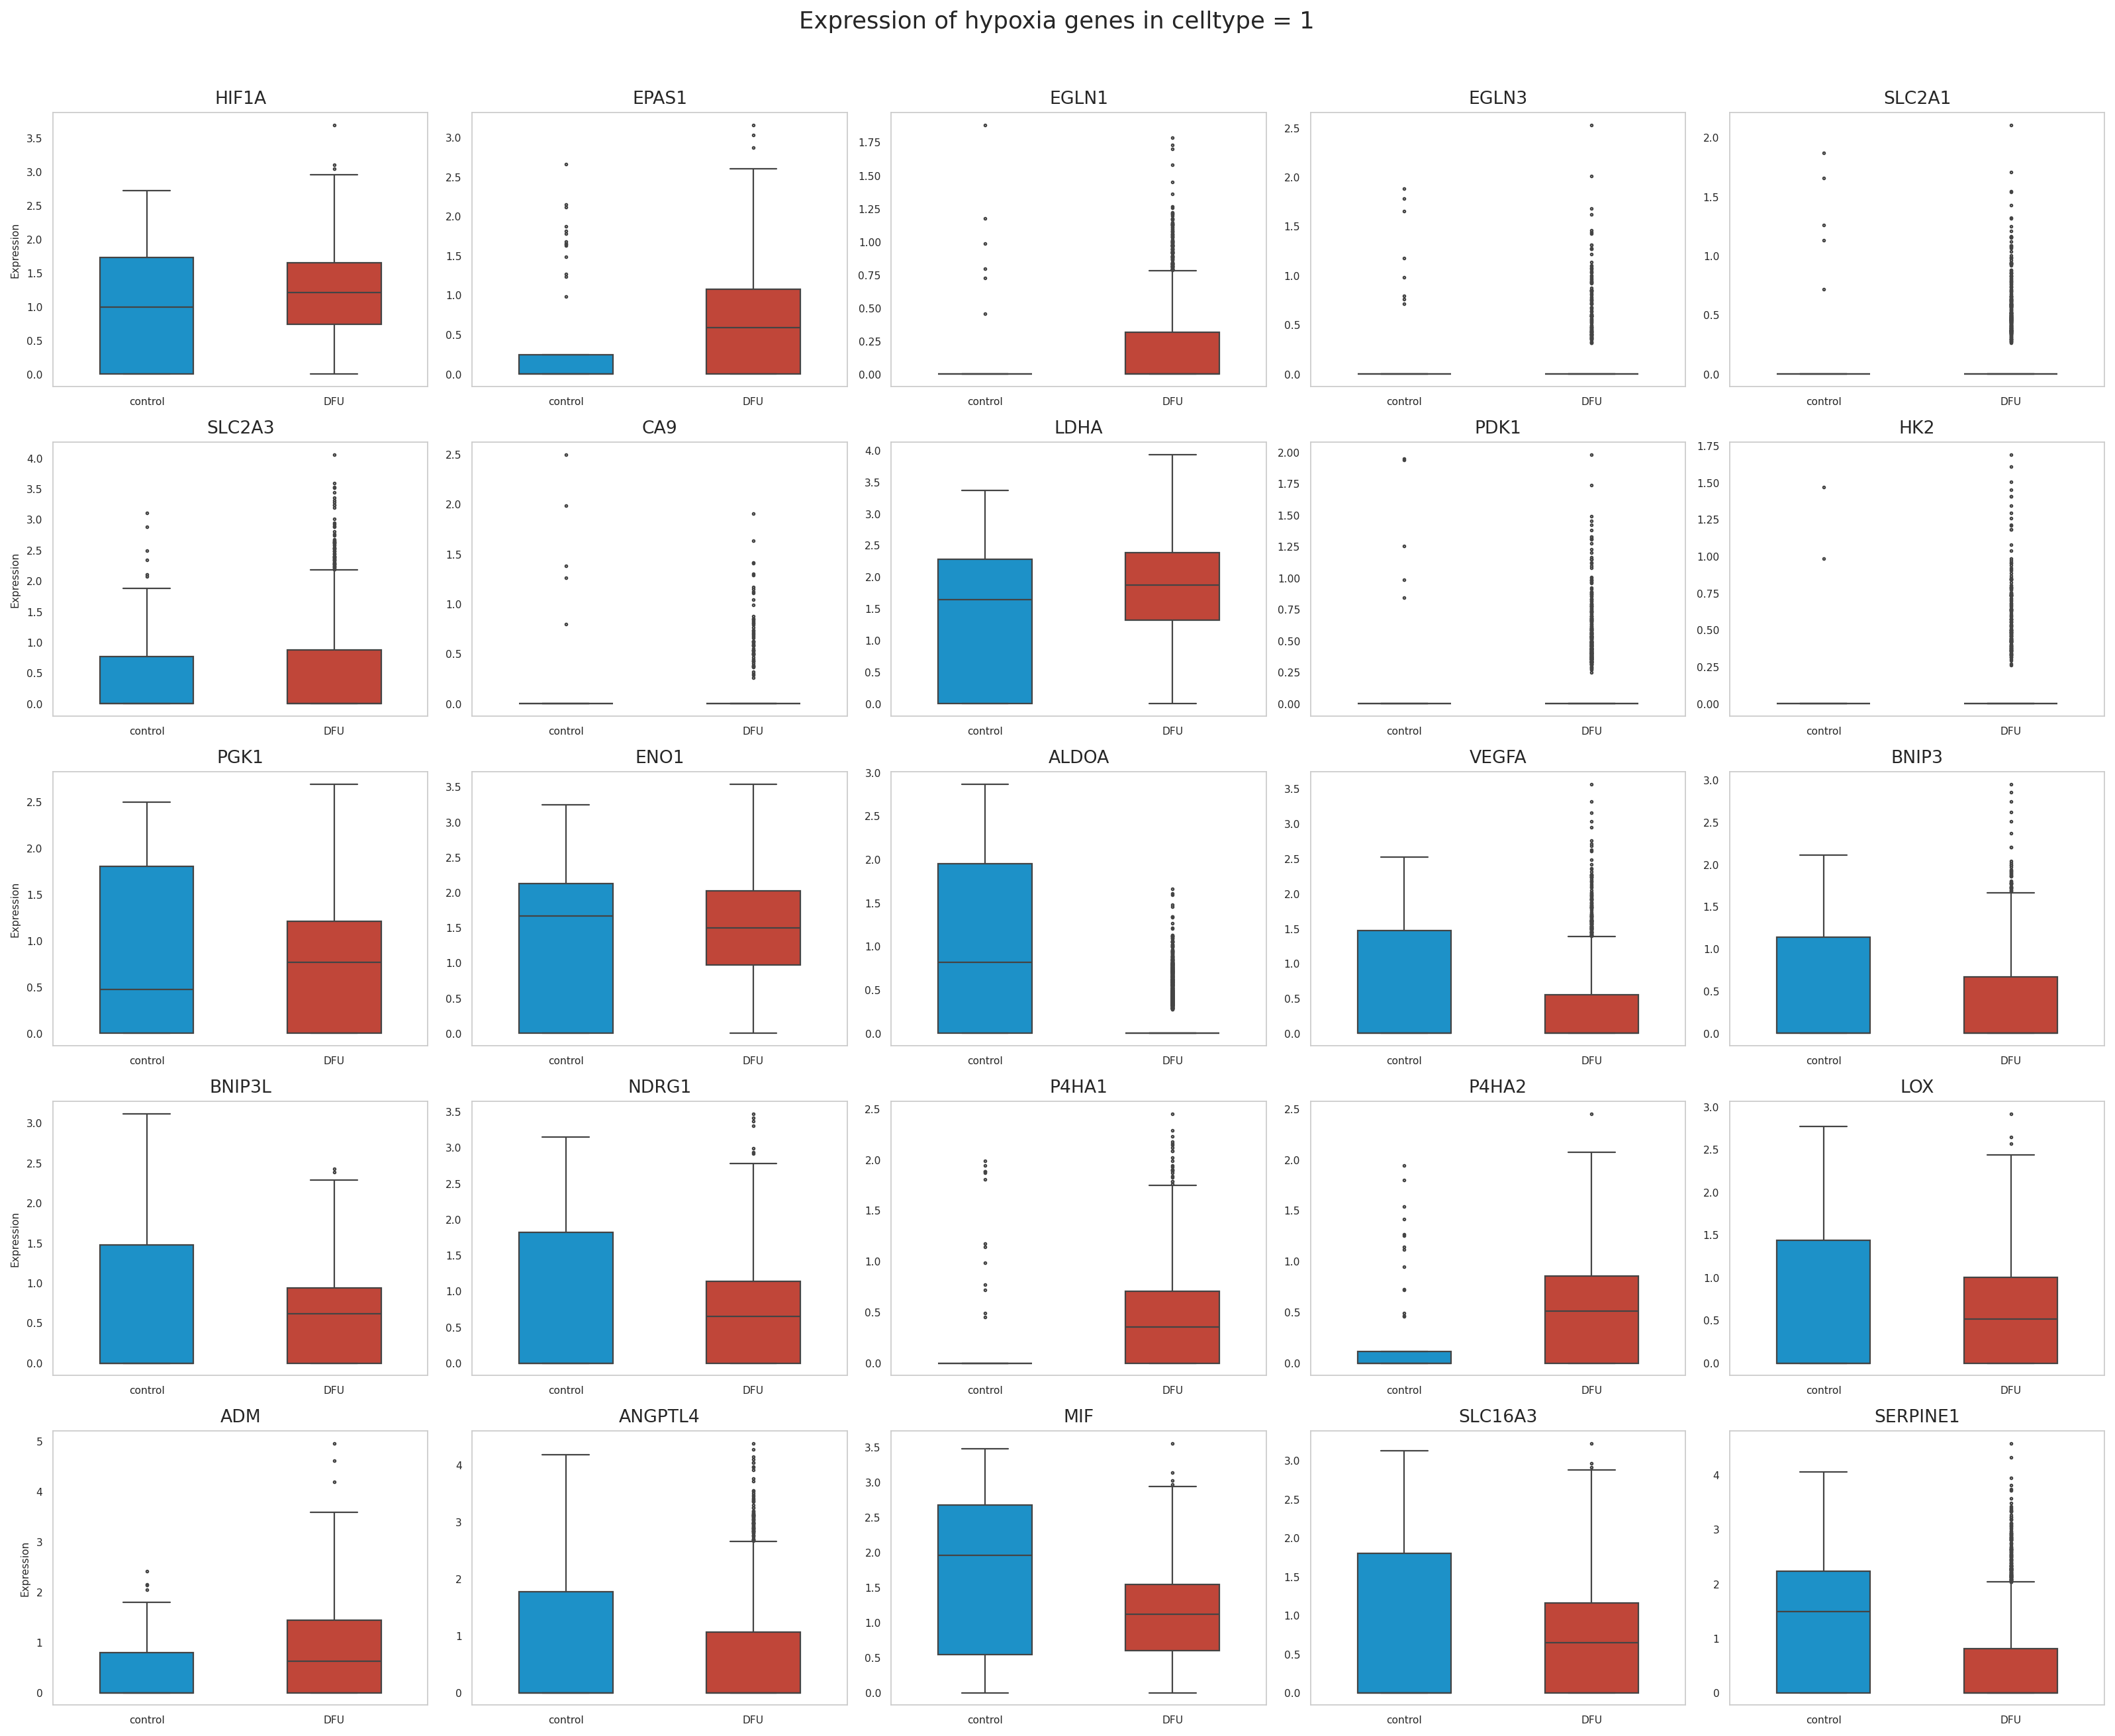

In [24]:
from pathlib import Path
gene_list = ['HIF1A', 'EPAS1', 'EGLN1', 'EGLN3', 'SLC2A1', 'SLC2A3',
             'CA9', 'LDHA', 'PDK1', 'HK2', 'PGK1', 'ENO1', 'ALDOA',
             'VEGFA', 'BNIP3', 'BNIP3L', 'NDRG1', 'P4HA1', 'P4HA2',
             'LOX', 'ADM', 'ANGPTL4', 'MIF', 'SLC16A3', 'SERPINE1']

adata_st = adata.raw.to_adata()
adata_sub = adata_st[adata_st.obs['celltype'] == '1'].copy()

missing = [g for g in gene_list if g not in adata_sub.var_names]
if missing:
    raise ValueError(f"以下基因不在 var_names 中：{missing}")

df_expr = sc.get.obs_df(adata_sub, keys=gene_list, use_raw=adata_sub.raw is not None)
df_expr['group'] = adata_sub.obs['group'].values
df_long = df_expr.melt(id_vars='group', value_vars=gene_list,
                       var_name='gene', value_name='expr')

sns.set_style('whitegrid')
fig, axes = plt.subplots(5, 5, figsize=(20, 16))
axes = axes.flatten()

for i, gene in enumerate(gene_list):
    ax = axes[i]
    sns.boxplot(data=df_long[df_long['gene'] == gene],
                x='group', y='expr', order=['control', 'DFU'],
                palette={'control': '#009CE4', 'DFU': '#D63423'},
                width=0.5, fliersize=1.5, linewidth=1, ax=ax)
    ax.set_title(gene, fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('Expression' if i % 5 == 0 else '')
    ax.grid(False)

for j in range(len(gene_list), 25):
    fig.delaxes(axes[j])

plt.suptitle('Expression of hypoxia genes in celltype = 1', y=1.02, fontsize=16)
plt.tight_layout()

out_path = Path("celltype1_hypoxia_genes.pdf")
plt.savefig(out_path, dpi=300, bbox_inches='tight')
plt.show()

In [9]:
genes_of_interest = ['HIF1A', 'EPAS1', 'EGLN1', 'SLC2A3', 'LDHA',
                     'ENO1', 'VEGFA',  'P4HA1', 'P4HA2', 'ADM']
print([gene for gene in genes_of_interest if gene in adata.raw.var_names])

['HIF1A', 'EPAS1', 'EGLN1', 'SLC2A3', 'LDHA', 'ENO1', 'VEGFA', 'P4HA1', 'P4HA2', 'ADM']


In [10]:
valid_genes = [gene for gene in genes_of_interest if gene in adata.raw.var_names]
adata_subset = adata.raw[:, valid_genes].to_adata()

/cluster/home/chenyulong/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [11]:
adata_subset.write("subset_genes.h5ad")

In [12]:
adata_subset.obs = adata.obs
adata_subset.var = adata.raw.var.loc[valid_genes]

In [13]:
adata_loaded = sc.read("subset_genes.h5ad")
print(adata_loaded)

AnnData object with n_obs × n_vars = 13214 × 10
    obs: 'sample', 'doublet_score', 'predicted_doublet', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'group', 'celltype'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'celltype_colors', 'group_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'sample_colors', 'scrublet', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    obsp: 'connectivities', 'distances'


/cluster/home/chenyulong/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [14]:
def calculate_signature_per_cell(adata, genes):
    """
    计算每个细胞的 signature 值，基于给定基因的表达值之和。
    """
    expression_matrix = adata[:, genes].X.toarray() if hasattr(adata.X, "toarray") else adata[:, genes].X
    signatures = np.sum(expression_matrix, axis=1)
    return signatures

def analyze_signature_by_leiden(adata, signatures, leiden_col='leiden'):
    """
    基于 `leiden` 聚类，统计 signature 的均值、标准差等信息。
    """
    adata.obs['Signature'] = signatures 
    

    summary_df = adata.obs.groupby(leiden_col)['Signature'].agg(['mean', 'median', 'std', 'count']).reset_index()
    summary_df.rename(columns={
        'mean': 'MeanSignature',
        'median': 'MedianSignature',
        'std': 'StdDevSignature',
        'count': 'CellCount'
    }, inplace=True)
    return summary_df


genes_of_interest = ['HIF1A', 'EPAS1', 'EGLN1', 'SLC2A3', 'LDHA',
                     'ENO1', 'VEGFA',  'P4HA1', 'P4HA2', 'ADM']


signatures = calculate_signature_per_cell(adata_loaded, genes_of_interest)


signature_summary_by_leiden = analyze_signature_by_leiden(adata_loaded, signatures)


signatures_with_leiden = pd.DataFrame({'Signature': signatures, 'leiden': adata_loaded.obs['leiden']})


with pd.ExcelWriter("leiden_signatures.xlsx") as writer:
    signatures_with_leiden.to_excel(writer, sheet_name='CellSignatures', index=False)
    signature_summary_by_leiden.to_excel(writer, sheet_name='LeidenSummary', index=False)

/tmp/ipykernel_156059/130051793.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_df = adata.obs.groupby(leiden_col)['Signature'].agg(['mean', 'median', 'std', 'count']).reset_index()


In [15]:
adata_loaded.obs

,sample,doublet_score,predicted_doublet,n_genes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,leiden,group,celltype,Signature
AAACGGGAGGCTACGA,G1A,0.030257,False,2730,2730,9072.0,142.0,1.565256,4,control,4,8.575190
AAAGATGGTCAGAGGT,G1A,0.009174,False,1078,1078,2467.0,30.0,1.216052,4,control,4,4.106441
AAAGATGGTCCAAGTT,G1A,0.022915,False,1648,1648,3816.0,55.0,1.441300,4,control,4,5.817848
AAAGCAAAGCGTTTAC,G1A,0.021714,False,1635,1635,3871.0,85.0,2.195815,4,control,4,8.018796
AAAGCAAAGTAGTGCG,G1A,0.017436,False,1653,1653,3655.0,43.0,1.176471,4,control,4,6.680474
...,...,...,...,...,...,...,...,...,...,...,...,...
TTCTTGACACAGTGAG-1,G49,0.033690,False,1123,1123,3851.0,202.0,5.245391,0,DFU,0,7.456872
TTGATGGTCGAGCCTG-1,G49,0.023162,False,1761,1761,5637.0,491.0,8.710307,0,DFU,0,6.575707
TTGCGTCGTATGATCC-1,G49,0.034801,False,691,691,1306.0,73.0,5.589586,0,DFU,0,6.245534
TTTACCAAGAACAAGG-1,G49,0.064359,False,2622,2622,7772.0,858.0,11.039630,0,DFU,0,7.882036


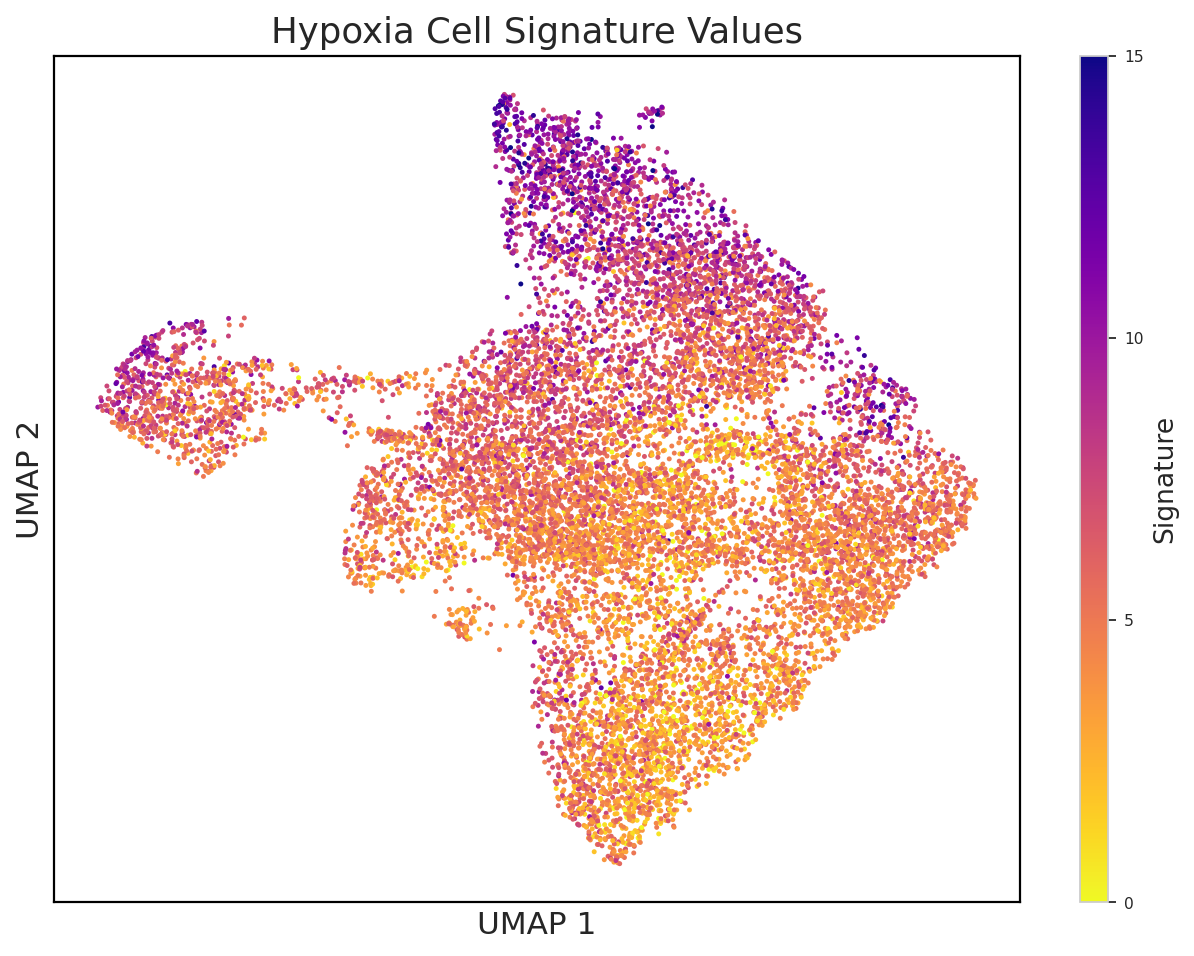

In [95]:
umap_coords = adata_loaded.obsm['X_umap']
adata_loaded.obs['UMAP_1'] = umap_coords[:, 0]
adata_loaded.obs['UMAP_2'] = umap_coords[:, 1]

plot_data = adata_loaded.obs[['UMAP_1', 'UMAP_2', 'Signature']]

plt.figure(figsize=(8, 6))
sc = plt.scatter(
    x=plot_data['UMAP_1'], 
    y=plot_data['UMAP_2'], 
    c=plot_data['Signature'], 
    cmap='plasma_r',        
    edgecolor='none', 
    s=5,                 
    vmin=0,           
    vmax=15             
)


plt.grid(False)


plt.xticks([])
plt.yticks([])


cb = plt.colorbar(sc, aspect=30)
cb.set_label('Signature', fontsize=12)
cb.set_ticks([0, 5, 10, 15])  


plt.title("Hypoxia Cell Signature Values", fontsize=16)
plt.xlabel("UMAP 1", fontsize=14)
plt.ylabel("UMAP 2", fontsize=14)


plt.gca().spines['top'].set_color('black')
plt.gca().spines['right'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.gca().spines['bottom'].set_color('black')


plt.gca().spines['top'].set_linewidth(1.0)
plt.gca().spines['right'].set_linewidth(1.0)
plt.gca().spines['left'].set_linewidth(1.0)
plt.gca().spines['bottom'].set_linewidth(1.0)


plt.tight_layout()


plt.savefig("Hypoxia_signature_colored.pdf", dpi=600, bbox_inches='tight')


plt.show()

/cluster/home/chenyulong/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


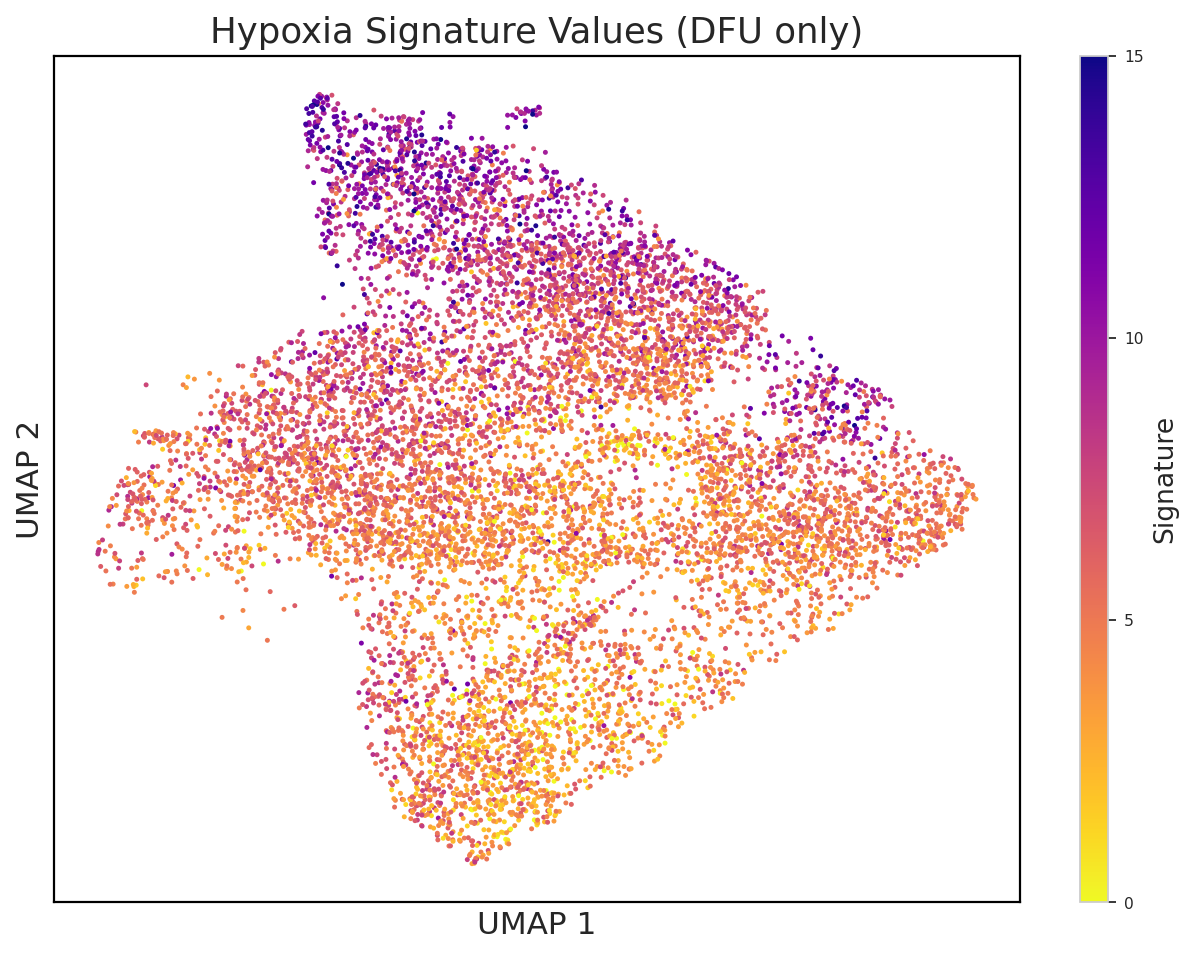

In [93]:
dfuadata_loaded = adata_loaded[adata_loaded.obs['group'] == 'DFU'].copy()

umap_coords = dfuadata_loaded.obsm['X_umap']
dfuadata_loaded.obs['UMAP_1'] = umap_coords[:, 0]
dfuadata_loaded.obs['UMAP_2'] = umap_coords[:, 1]

plot_data = dfuadata_loaded.obs[['UMAP_1', 'UMAP_2', 'Signature']]

plt.figure(figsize=(8, 6))
sc = plt.scatter(
    x=plot_data['UMAP_1'],
    y=plot_data['UMAP_2'],
    c=plot_data['Signature'],
    cmap='plasma_r',
    edgecolor='none',
    s=5,
    vmin=0,
    vmax=15
)
plt.grid(False)
plt.xticks([])
plt.yticks([])
cb = plt.colorbar(sc, aspect=30)
cb.set_label('Signature', fontsize=12)
cb.set_ticks([0, 5, 10, 15])
plt.title("Hypoxia Signature Values (DFU only)", fontsize=16)
plt.xlabel("UMAP 1", fontsize=14)
plt.ylabel("UMAP 2", fontsize=14)
for sp in plt.gca().spines.values():
    sp.set_color('black')
    sp.set_linewidth(1.0)
plt.tight_layout()
plt.savefig("Hypoxia_signature_colored_DFU.pdf", dpi=600, bbox_inches='tight')
plt.show()

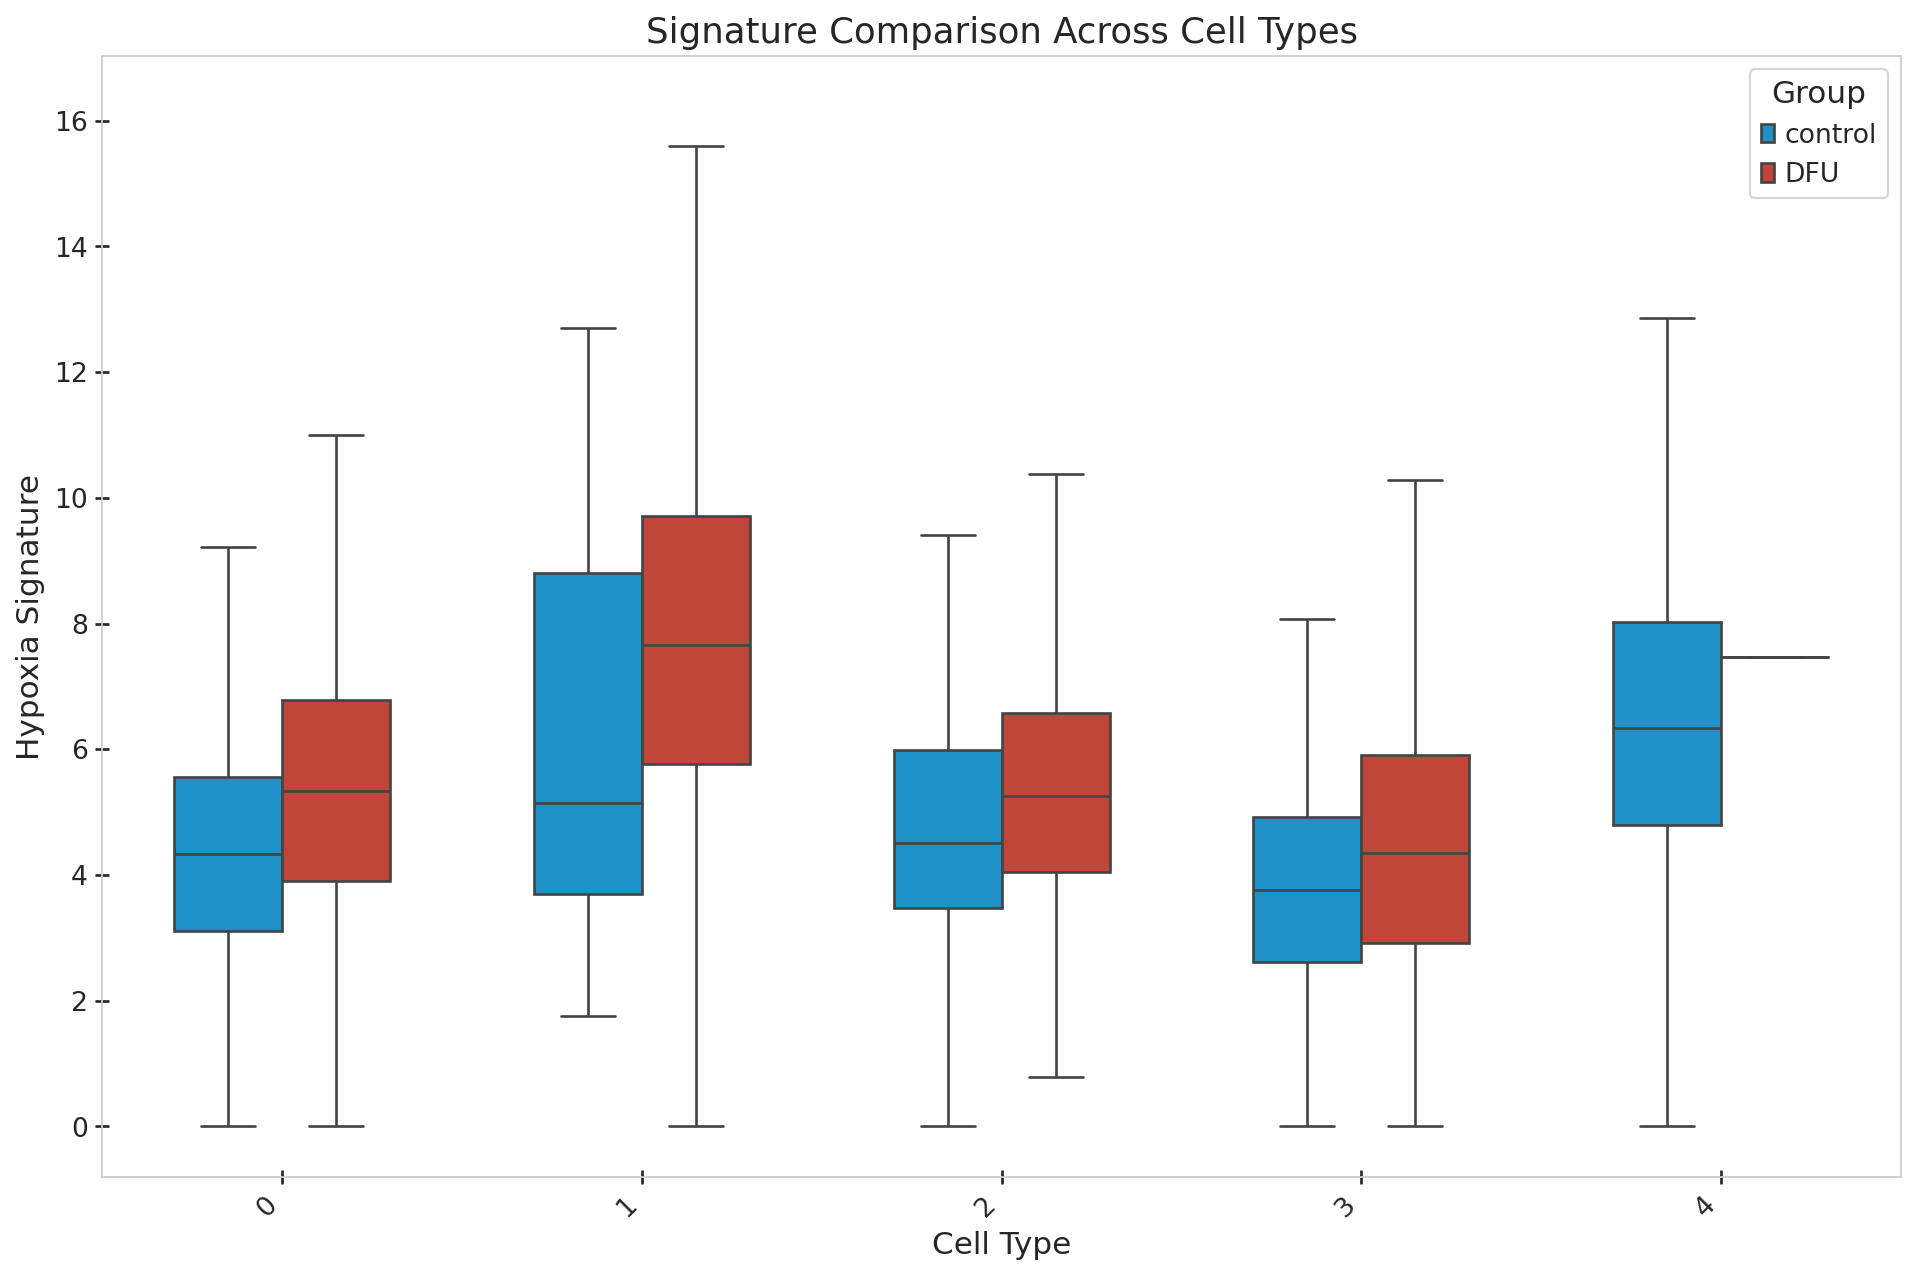

In [86]:
plot_data = adata_loaded.obs[['celltype', 'group', 'Signature']].dropna()

if plot_data.empty:
    print("No data available for plotting. Please check the dataset.")
else:
    
    plt.figure(figsize=(12, 8))
    sns.boxplot(
        x='celltype', 
        y='Signature', 
        hue='group', 
        data=plot_data, 
        width=0.6,  
        palette={'control': '#009CE4', 'DFU': '#D63423'},  
        linewidth=1.2,  
        fliersize=0, 
        hue_order=['control', 'DFU'] 
    )


    plt.title("Signature Comparison Across Cell Types", fontsize=16)
    plt.xlabel("Cell Type", fontsize=14)
    plt.ylabel("Hypoxia Signature", fontsize=14)


    plt.xticks(fontsize=12, rotation=45, ha='right') 
    plt.yticks(fontsize=12)
    
    plt.tick_params(
        axis='both',          
        which='major',        
        length=6,             
        width=1.2,            
        direction='inout',   
        left=True,          
        bottom=True,       
        top=False,          
        right=False           
    )


    plt.grid(False)

    plt.legend(title='Group', fontsize=12, title_fontsize=14, loc='upper right')

    plt.tight_layout()

    plt.savefig("Hypoxia_signature_boxplot_all_celltypes.pdf", dpi=300, bbox_inches='tight')

    plt.show()

In [88]:
import itertools

cell_types = adata_loaded.obs['celltype'].unique()

results = []

for cell_type in cell_types:
    subset_data = adata_loaded.obs[adata_loaded.obs['celltype'] == cell_type]
    
    group1_data = subset_data[subset_data['group'] == 'control']['Signature'].dropna()
    group2_data = subset_data[subset_data['group'] == 'DFU']['Signature'].dropna()

    if not group1_data.empty and not group2_data.empty:
    
        stat, p_value = mannwhitneyu(group1_data, group2_data, alternative='two-sided')
        results.append({'celltype': cell_type, 'p_value': p_value})
    else:
     
        results.append({'celltype': cell_type, 'p_value': None})

for result in results:
    print(f"Cell Type: {result['celltype']}, P-Value: {result['p_value']}")

Cell Type: 4, P-Value: 0.5731051908546962
Cell Type: 0, P-Value: 5.593688829808964e-51
Cell Type: 1, P-Value: 0.00027292544668805843
Cell Type: 2, P-Value: 1.448225416346304e-10
Cell Type: 3, P-Value: 6.519568134427201e-09


/tmp/ipykernel_300638/3619324420.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


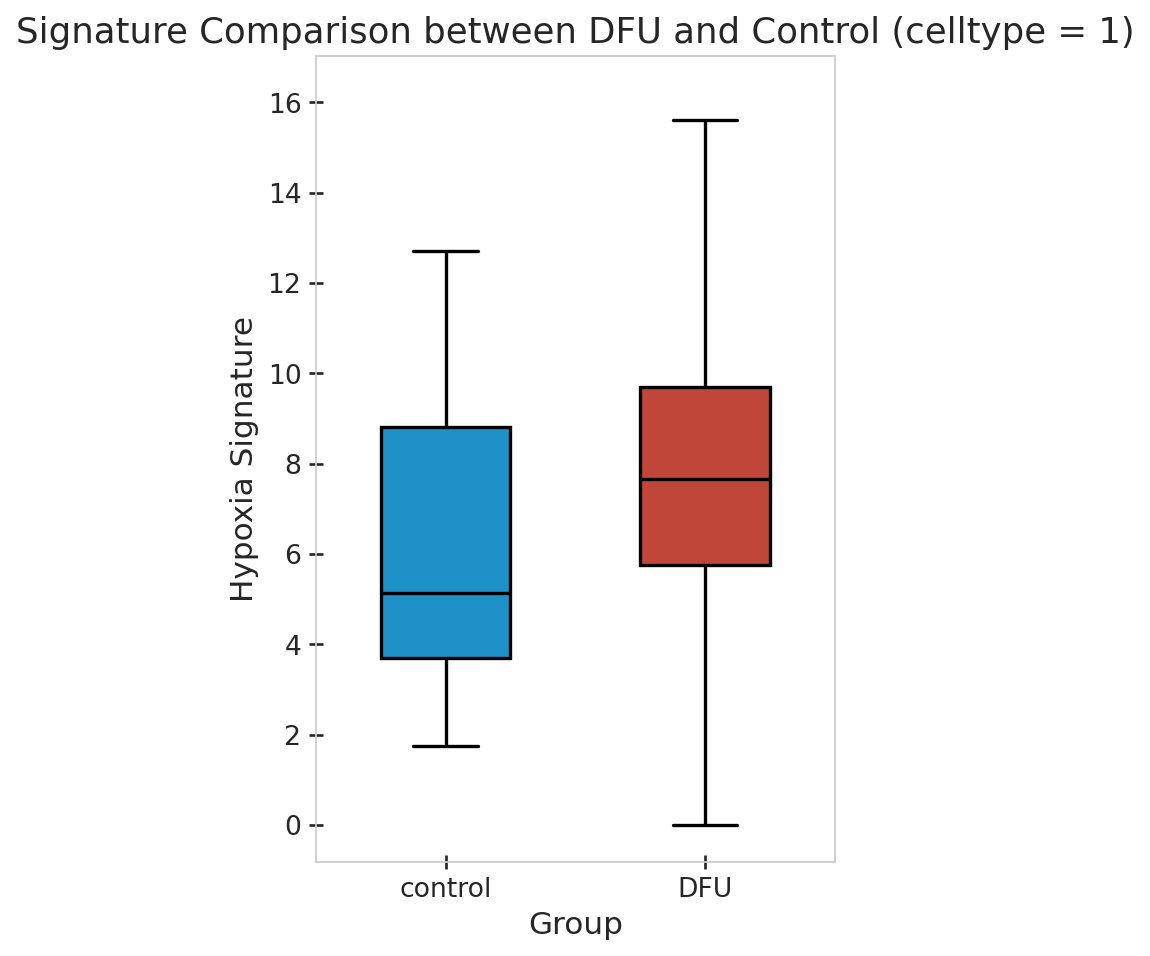

In [87]:
subset_data = adata_loaded.obs[adata_loaded.obs['celltype'] == '1'][['group', 'Signature']].dropna()


if subset_data.empty:
    print("No data available for celltype == '1'. Please check the dataset.")
else:
 
    plt.figure(figsize=(4, 6))

    sns.boxplot(
        x='group',
        y='Signature',
        data=subset_data,
        width=0.5,
        fliersize=0,
        linewidth=0.8,
        order=['control', 'DFU'],
        palette={'control': '#009CE4', 'DFU': '#D63423'},
        boxprops=dict(edgecolor='black', linewidth=1.5),
        whiskerprops=dict(color='black', linewidth=1.5),
        capprops=dict(color='black', linewidth=1.5),
        medianprops=dict(color='black', linewidth=1.5)
    )

    plt.title("Signature Comparison between DFU and Control (celltype = 1)", fontsize=16)
    plt.xlabel("Group", fontsize=14)
    plt.ylabel("Hypoxia Signature", fontsize=14)
    plt.tick_params(
        axis='both',          
        which='major',       
        length=6,             
        width=1.2,            
        direction='inout',    
        left=True,         
        bottom=True,        
        top=False,       
        right=False            
    )
    #plt.ylim(-2, 12)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(False)
    plt.tight_layout()
    plt.savefig("Hypoxia_signature_celltype1.pdf", dpi=300, bbox_inches='tight')
    plt.show()

In [74]:
dfu_data = adata_loaded.obs[
    (adata_loaded.obs['group'] == 'DFU') & 
    (adata_loaded.obs['celltype'] == '1')
]['Signature'].dropna()

control_data = adata_loaded.obs[
    (adata_loaded.obs['group'] == 'control') & 
    (adata_loaded.obs['celltype'] == '1')
]['Signature'].dropna()

if not dfu_data.empty and not control_data.empty:
    stat, p_value = mannwhitneyu(control_data, dfu_data, alternative='two-sided')
    print(f"celltype = 1  P-Value between DFU and Control: {p_value}")
else:
    print("celltype = 1  的 DFU 或 Control 组数据为空，无法计算 P 值。")

celltype = 1  P-Value between DFU and Control: 0.00027292544668805843
